In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.manifold import TSNE
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

I0000 00:00:1776797533.834736   41077 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776797533.885188   41077 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776797535.809499   41077 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
DATASET = "caltech-101"
CLASSES = {"airplanes", "accordion", "anchor"}

In [4]:
model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

E0000 00:00:1776797559.080489   41077 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776797559.080867   41636 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776797559.101677   41077 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
def get_feat(p):
    img = preprocess_input(
        np.expand_dims(
            image.img_to_array(image.load_img(p, target_size=(224, 224))), 0
        )
    )
    return model.predict(img, verbose=0).flatten()

In [6]:
features, labels = zip(*[
    (get_feat(os.path.join(DATASET, c, f)), c)
    for c in os.listdir(DATASET) if c in CLASSES
    for f in tqdm(os.listdir(os.path.join(DATASET, c)))
])

100%|██████████████████████████████████████████████████████████████| 42/42 [00:04<00:00, 10.25it/s]


In [7]:
features = np.array(features)
print("Total images:", len(features))

Total images: 897


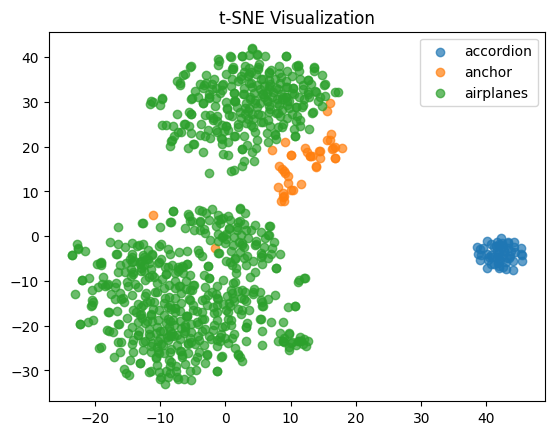

In [8]:
feat_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(features)

# Plot
for lbl in set(labels):
    idx = [i for i, l in enumerate(labels) if l == lbl]
    plt.scatter(feat_2d[idx, 0], feat_2d[idx, 1], label=lbl, alpha=0.7)

plt.title("t-SNE Visualization")
plt.legend()
plt.show()